# Training the models

## 1. Linear Regression

We will be training a closed form equation first and foremost! 
Closed form equation directly solves for the parameters, without any approximations (Like simple gradien descent or SGD).
While training implies that model will essentially learn the set of best parameters for the cause with few iterations; with a closed form equations, we essentially calculate the correct set of parameters in just one go!
It is due to this fact that some argue we aren't "training" the model so much as we are simply solving it.

In [13]:
import numpy as np
from sklearn.preprocessing import add_dummy_feature

#Equation of simple line is y = b+ax... However for the matrix math in ML we prefer the form of y = theta * x. So for this we need a format of [1, theta]

rng = np.random.default_rng(seed = 42)
m = 200 #Number of rows
x = 2*rng.random((m,1)) #Coulmn Vector ie.- it only has rows
y = 3 * x + 4 + rng.standard_normal((m, 1)) #Added just a little bit of noise
x_b = add_dummy_feature(x) #This code by default adds x0 as 1.

$$\mathbf{y} = \mathbf{X} \cdot \boldsymbol{\theta}$$

But we need to ensure that the matrix of $\mathbf{X}$ remains square, as the inverse is only possible when we have a square matrix. To ensure this, we multiply both sides with $\mathbf{X}^T$:

$$\mathbf{X}^T \cdot \mathbf{y} = \mathbf{X}^T \cdot \mathbf{X} \cdot \boldsymbol{\theta}$$

Therefore:

$$\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \cdot \mathbf{X}^T \cdot \mathbf{y}$$



In [14]:
theta = np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y
theta

array([[3.69084138],
       [3.32960458]])

In [16]:
#Lets verify once:

x_new = np.array([[0], [2]])
x_new_b = add_dummy_feature(x_new)
y_predict = x_new_b @ theta
y_predict

array([[ 3.69084138],
       [10.35005055]])

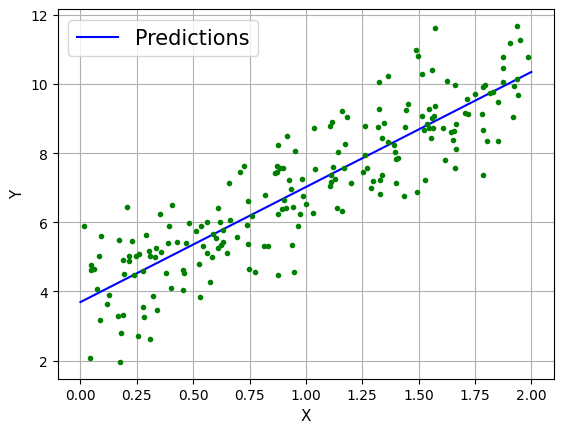

In [35]:
import matplotlib.pyplot as plt

plt.plot(x_new, y_predict, "b", label ='Predictions')
plt.plot(x, y, "g.")
plt.grid(True)
plt.xlabel('X', fontsize = 11)
plt.ylabel('Y', fontsize = 11)
plt.legend(loc = 'upper left', fontsize = 15)
plt.show()

### Let us try linear regression via scikit-learn:

In [36]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x, y)
print(lin_reg.intercept_, lin_reg.coef_) #Bias vs feature weights
print(lin_reg.predict(x_new))

[3.69084138] [[3.32960458]]
[[ 3.69084138]
 [10.35005055]]


##### Lets look deeply into the concept of SVD asnd psuedo-inverse of the matrices, why are they needed, how they solve the problem, etc.


We start with the linear system:

$$\mathbf{y} = X \boldsymbol{\theta}$$

* Apply Singular Value Decomposition (SVD) to $X$:

$$X = U \Sigma V^T$$

Substitute into the original equation:

$$U \Sigma V^T \boldsymbol{\theta} = \mathbf{y}$$

Multiply both sides by $U^T$:

$$\Sigma V^T \boldsymbol{\theta} = U^T \mathbf{y}$$
(because u and v are unit matrices)

Define:

$$\mathbf{z} = V^T \boldsymbol{\theta}, \quad \mathbf{c} = U^T \mathbf{y}$$

Then:

$$\Sigma \mathbf{z} = \mathbf{c}$$

As $\Sigma$ is always a diagonal matrix, this gives a system of equations:

$$\sigma_i \, z_i = c_i$$

So,

$$z_i = \frac{c_i}{\sigma_i}$$

Recover $\boldsymbol{\theta}$:

$$\boldsymbol{\theta} = V \mathbf{z}$$

Thus, the solution becomes:

$$\boldsymbol{\theta} = V \Sigma^{-1} U^T \mathbf{y}$$

* Pseudo-Inverse (General Case)

If some singular values $\sigma_i = 0$, we use the pseudo-inverse:

$$\boldsymbol{\theta} = V \Sigma^+ U^T \mathbf{y}$$

To compute $\Sigma^+$ the algorithm takes $\Sigma$ and set all the values less than the given threshold (which by the is small itself) as zero and replaces nonzero values with their inverse and finally transpose the resultring matrix. 

* NOTE: For some matrices, inverse may not be defined, but pseudo-inverse will always be defined in any case!|

In [40]:
theta_svd, residuals, rank, s = np.linalg.lstsq(x_b, y, rcond=1e-6)
print(theta_svd)
print(np.linalg.pinv(x_b) @ y)

[[3.69084138]
 [3.32960458]]
[[3.69084138]
 [3.32960458]]


Time Complexity of normal/closed form inverse method is $O(n^{2.4})$ to $O(n^3)$; meanwhile SVD or pseudo-inverse technique takes $O(n^2)$. Therefore it is not advised to use either of them, especially in terms of larger models, where we have more features, more variables and more dimensions.

## 2. Gradient Descent

The Mean-Squared loss function or MSE for the linear regression algorithm is guaranteed to have the *<u>CONVEX</u>* landscape. 

### Batch/Full Gradient Descent

In [48]:
eta = 0.01
n_epochs = 7500
m = len(x_b)

theta = rng.standard_normal((2,1))

for epoch in range(n_epochs):
    gradients = 2/m * x_b.T @ (x_b @ theta - y)
    theta = theta - eta*gradients

theta

array([[3.69084138],
       [3.32960458]])

In [61]:
eta = 0.1
n_epochs = 750
m = len(x_b)

theta = rng.standard_normal((2,1))

for epoch in range(n_epochs):
    gradients = 2/m * x_b.T @ (x_b @ theta - y)
    theta = theta - eta*gradients

theta

array([[3.69084138],
       [3.32960458]])

In [65]:
eta = 0.2
n_epochs = 300
m = len(x_b)

theta = rng.standard_normal((2,1))

for epoch in range(n_epochs):
    gradients = 2/m * x_b.T @ (x_b @ theta - y)
    theta = theta - eta*gradients

theta

array([[3.69084138],
       [3.32960458]])